###Import Statements

In [1]:
import itertools
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import csv
import time

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Functions for fault model simulation and fault detection

In [2]:

# ---------- Fault Model ---------- #
def simulate_circuit(circuit, vec):
    vec = vec.copy()
    for gate in circuit:
        if gate[0] == "TOFFOLI":
            controls, target = gate[1], gate[2]
            if all(vec[c] == 1 for c in controls):
                vec[target] ^= 1
        elif gate[0] == "FREDKIN":
            ctrl, s1, s2 = gate[1]
            if vec[ctrl] == 1:
                vec[s1], vec[s2] = vec[s2], vec[s1]
    return vec

def simulate_faulty_saf(circuit, input_vector, fault):
    vec = input_vector.copy()
    for i, gate in enumerate(circuit):
        if i == fault["location"]:
            vec[fault["wire"]] = fault["value"]
        if gate[0] == "TOFFOLI":
            controls, target = gate[1], gate[2]
            if all(vec[c] == 1 for c in controls):
                vec[target] ^= 1
        elif gate[0] == "FREDKIN":
            ctrl, s1, s2 = gate[1]
            if vec[ctrl] == 1:
                vec[s1], vec[s2] = vec[s2], vec[s1]
    return vec


def generate_fault_list_with_types(circuit, n_inputs):
    fault_list = []
    # Single Missing Gate Faults
    for i in range(len(circuit)):
        faulty_circuit = circuit[:i] + circuit[i+1:]
        fault_list.append({"id": f"MGF_{i}", "type": "MGF", "circuit": faulty_circuit})
    # Stuck-at Faults
    for gate_idx in range(len(circuit)):
        for wire in range(n_inputs):
            for val in [0, 1]:
                fault_list.append({
                    "id": f"SAF_{gate_idx}_{wire}_{val}",
                    "type": "SAF",
                    "location": gate_idx,
                    "wire": wire,
                    "value": val,
                    "circuit": circuit
                })
    return fault_list


def detect_fault(dp, vector, fault, circuit):
    key = (tuple(vector), fault["id"])
    if key in dp:
        return dp[key]
    normal_output = simulate_circuit(circuit, vector)
    if fault["type"] == "MGF":
        faulty_output = simulate_circuit(fault["circuit"], vector)
    elif fault["type"] == "SAF":
        faulty_output = simulate_faulty_saf(circuit, vector, fault)
    else:
        faulty_output = normal_output  # No-op for unknown
    detected = normal_output != faulty_output
    dp[key] = detected
    return detected


###Fitness Calulation

In [3]:
# ---------- Fitness ---------- #
def compute_fitness(individual, fault_list, circuit, dp, alpha=1.0, beta=0.1):
    detected_faults = set()
    for vector in individual:
        for fault in fault_list:
            if detect_fault(dp, vector, fault, circuit):
                detected_faults.add(fault["id"])
    coverage = len(detected_faults) / len(fault_list)
    fitness = alpha * coverage - beta * len(individual)
    return fitness, coverage, detected_faults

###Mutation and Crossover

In [4]:
# ---------- GA Operators ---------- #
def crossover(parent1, parent2):
    cut1 = random.randint(1, len(parent1) - 1)
    cut2 = random.randint(1, len(parent2) - 1)
    return parent1[:cut1] + parent2[cut2:]

def mutate(individual, mutation_rate=0.2):
    for vec in individual:
        if random.random() < mutation_rate:
            bit = random.randint(0, len(vec) - 1)
            vec[bit] ^= 1
    return individual

In [5]:
def remove_redundant_vectors(individual, circuit, fault_list):
    reduced = []
    dp = {}
    covered = set()
    for vec in individual:
        temp = covered.copy()
        for fault in fault_list:
            if fault["id"] not in covered and detect_fault(dp, vec, fault, circuit):
                covered.add(fault["id"])
        if temp != covered:
            reduced.append(vec)
    return reduced

###GA+DP Approach

In [6]:
# ---------- GA Core ---------- #
def run_ga(circuit, n_inputs, generations=30, pop_size=10, max_vecs=8, runs=3):
    fault_list = generate_fault_list_with_types(circuit, n_inputs)
    best_results = []
    for _ in range(runs):
        dp = {}
        population = [
            [[random.randint(0, 1) for _ in range(n_inputs)] for _ in range(random.randint(2, max_vecs))]
            for _ in range(pop_size)
        ]
        for _ in range(generations):
            fitness_scores = [compute_fitness(ind, fault_list, circuit, dp) for ind in population]
            population = [x for _, x in sorted(zip(fitness_scores, population), reverse=True)]
            next_gen = population[:pop_size // 2]
            while len(next_gen) < pop_size:
                p1, p2 = random.sample(next_gen, 2)
                child = crossover(p1, p2)
                child = mutate(child)
                next_gen.append(child)
            population = next_gen
        best = max(population, key=lambda ind: compute_fitness(ind, fault_list, circuit, dp)[0])
        best = remove_redundant_vectors(best, circuit, fault_list)
        best_fitness, coverage, detected_faults = compute_fitness(best, fault_list, circuit, dp)
        best_results.append((best, (best_fitness, coverage, len(fault_list), detected_faults)))
    return best_results


###Run over the benchmark circuits

In [7]:
# ---------- File Utilities ---------- #
def read_real_file(file_path):
    with open(file_path, 'r') as file:
        return file.readlines()

def parse_real_file_lines(real_lines):
    var_map = {}
    circuit = []
    for line in real_lines:
        if line.startswith(".variables"):
            vars_list = line.strip().split()[1:]
            var_map = {var: idx for idx, var in enumerate(vars_list)}
        elif line.startswith(".begin") or line.startswith(".end"):
            continue
        elif line.startswith("t"):
            tokens = line.strip().split()
            wires = [var_map[x] for x in tokens[1:]]
            if len(wires) == 1:
                circuit.append(("TOFFOLI", [], wires[0]))
            else:
                circuit.append(("TOFFOLI", wires[:-1], wires[-1]))
    return circuit, len(var_map)

In [8]:
# ---------- Batch Run ---------- #
def run_on_folder(folder_path, save_csv_path="ga_results.csv"):
    results = []
    folder = Path(folder_path)
    real_files = list(folder.glob("*.real"))
    for file in real_files:
        try:
            lines = read_real_file(file)
            circuit, n_inputs = parse_real_file_lines(lines)
            start_time = time.time()
            best_runs = run_ga(circuit, n_inputs)
            end_time = time.time()
            execution_time = round(end_time - start_time, 2)

            best_test_set, (fitness, coverage, total_faults, detected_faults) = max(best_runs, key=lambda x: x[1][0])
            results.append({
                "file": file.name,
                "fitness": round(fitness, 4),
                "coverage": round(coverage, 4),
                "total_faults": total_faults,
                "detected_faults": len(detected_faults),
                "detected_ids": list(sorted(detected_faults)),
                "test_vectors": best_test_set,
                "num_test_vectors": len(best_test_set),
                "num_gates": len(circuit),
                "exec_time_sec": execution_time
            })

        except Exception as e:
            results.append({"file": file.name, "fitness": "ERROR", "coverage": "ERROR", "total_faults": "ERROR", "detected_faults": "ERROR", "detected_ids": None, "test_vectors": None, "num_test_vectors": None, "num_gates": None, "error": str(e)})
    with open(save_csv_path, "w", newline='') as f:
        writer = csv.DictWriter(f, fieldnames=["file", "fitness", "coverage", "total_faults", "detected_faults", "num_test_vectors", "num_gates", "exec_time_sec"])
        writer.writeheader()
        for row in results:
            if row["fitness"] != "ERROR":
                writer.writerow({key: row[key] for key in writer.fieldnames})

    return results


###Visualiza the Results

In [9]:
def plot_gates_coverage_vectors(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]

    files = [r["file"] for r in filtered]
    num_gates = [r["num_gates"] for r in filtered]
    coverage = [r["coverage"] for r in filtered]
    num_vectors = [r["num_test_vectors"] for r in filtered]

    x = np.arange(len(files))
    fig, ax1 = plt.subplots(figsize=(14, 6))

    bars = ax1.bar(x - 0.2, num_gates, width=0.4, color='lightcoral', label="Gate Count")
    ax1.set_ylabel("Number of Gates", color="lightcoral")
    ax1.tick_params(axis='y', labelcolor="lightcoral")
    ax1.set_xticks(x)
    ax1.set_xticklabels(files, rotation=45, ha='right')

    ax2 = ax1.twinx()
    ax2.plot(x, coverage, color='royalblue', marker='o', label="Fault Coverage")
    ax2.set_ylabel("Coverage", color="royalblue")
    ax2.tick_params(axis='y', labelcolor="royalblue")
    ax2.set_ylim(0, 1.05)

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(x, num_vectors, color='darkgreen', marker='s', linestyle='--', label="Test Vectors")
    ax3.set_ylabel("Number of Test Vectors", color="darkgreen")
    ax3.tick_params(axis='y', labelcolor="darkgreen")

    plt.title("Gates, Coverage & Test Vectors per Circuit")
    fig.tight_layout()

    lines, labels = [], []
    for ax in [ax1, ax2, ax3]:
        for line in ax.get_lines():
            lines.append(line)
            labels.append(line.get_label())
    fig.legend(lines + [bars], labels + ["Gate Count"], loc="upper right", bbox_to_anchor=(1.15, 1))

    plt.show()

In [10]:
# ---------- Extra Analysis Charts with MGF and BFF Breakdown ---------- #
def extract_fault_breakdown(results):
    data = []
    for r in results:
        if r["fitness"] == "ERROR":
            continue
        mgf_detected = sum(1 for fid in r["detected_ids"] if fid.startswith("MGF"))
        saf_detected = sum(1 for fid in r["detected_ids"] if fid.startswith("SAF"))
        mgf_total = sum(1 for fid in r["detected_ids"] + ["dummy"]*r["total_faults"] if str(fid).startswith("MGF"))
        saf_total = r["total_faults"] - mgf_total
        data.append({
            "file": r["file"],
            "vectors": r["num_test_vectors"],
            "coverage": r["coverage"],
            "mgf_detected": mgf_detected,
            "saf_detected": saf_detected,
            "mgf_total": mgf_total,
            "saf_total": saf_total
        })
    return data



def plot_coverage_vs_vectors(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]
    x = [r["num_test_vectors"] for r in filtered]
    y = [r["coverage"] for r in filtered]
    labels = [r["file"] for r in filtered]

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, c='darkgreen', s=100)
    for i, label in enumerate(labels):
        plt.text(x[i]+0.02, y[i], label, fontsize=9)
    plt.xlabel("Number of Test Vectors")
    plt.ylabel("Fault Coverage")
    plt.title("Coverage vs Number of Test Vectors")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_detected_vs_total_faults(results):
    data = extract_fault_breakdown(results)
    x = [d["file"] for d in data]
    mgf_total = [d["mgf_total"] for d in data]
    mgf_detected = [d["mgf_detected"] for d in data]
    saf_total = [d["saf_total"] for d in data]
    saf_detected = [d["saf_detected"] for d in data]

    x_pos = np.arange(len(x))
    width = 0.2
    plt.figure(figsize=(14, 6))
    plt.bar(x_pos - width*1.5, mgf_total, width, label='MGF Total', color='lightgray')
    plt.bar(x_pos - width/2, mgf_detected, width, label='MGF Detected', color='orange')
    plt.bar(x_pos + width/2, saf_total, width, label='SAF Total', color='lightgray', hatch='//')
    plt.bar(x_pos + width*1.5, saf_detected, width, label='SAF Detected', color='seagreen')

    plt.xticks(x_pos, x, rotation=45, ha='right')
    plt.ylabel("Number of Faults")
    plt.title("Detected vs Total Faults for MGF and SAF")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_efficiency(results):
    data = extract_fault_breakdown(results)
    x = [d["file"] for d in data]
    efficiency = [(d["mgf_detected"] + d["saf_detected"]) / d["vectors"] if d["vectors"] > 0 else 0 for d in data]

    plt.figure(figsize=(10, 5))
    plt.bar(x, efficiency, color='slateblue')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Efficiency (Detected Faults per Vector)")
    plt.title("Test Vector Efficiency per Circuit")
    plt.tight_layout()
    plt.show()



In [11]:
# ---------- Example Usage ---------- #
input_folder_path = "/content/drive/MyDrive/Dissertation Work/Research Work/Medium Circuits"
results = run_on_folder(input_folder_path, save_csv_path="ga_results.csv")



Copy of hwb8_113.real → gates: 637, vectors: 3, time: 2658.07 sec
Copy of 4mod7-v0_94.real → gates: 6, vectors: 3, time: 0.12 sec
Copy of hwb6_56.real → gates: 126, vectors: 2, time: 44.53 sec


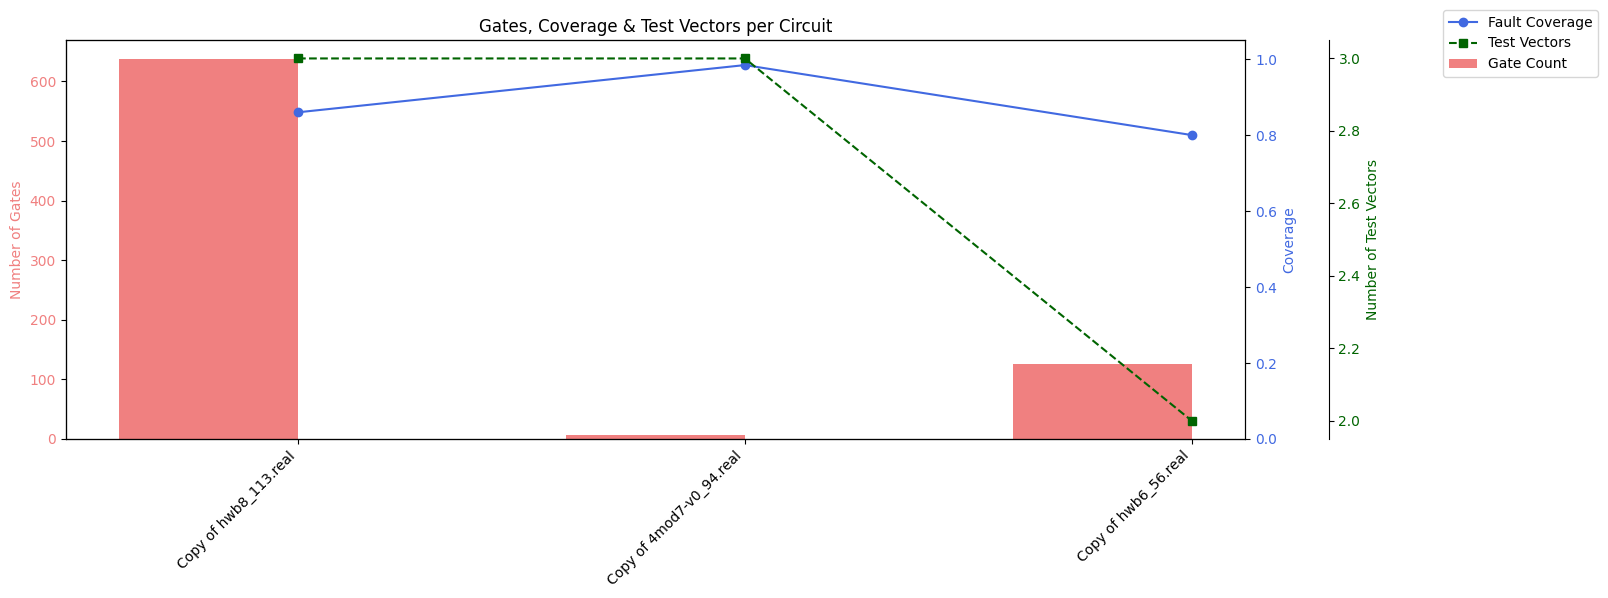

In [12]:
for r in results:
    print(f'{r["file"]} → gates: {r.get("num_gates")}, vectors: {r.get("num_test_vectors")}, time: {r.get("exec_time_sec")} sec')

plot_gates_coverage_vectors(results)
# ---------- Example Execution ---------- #



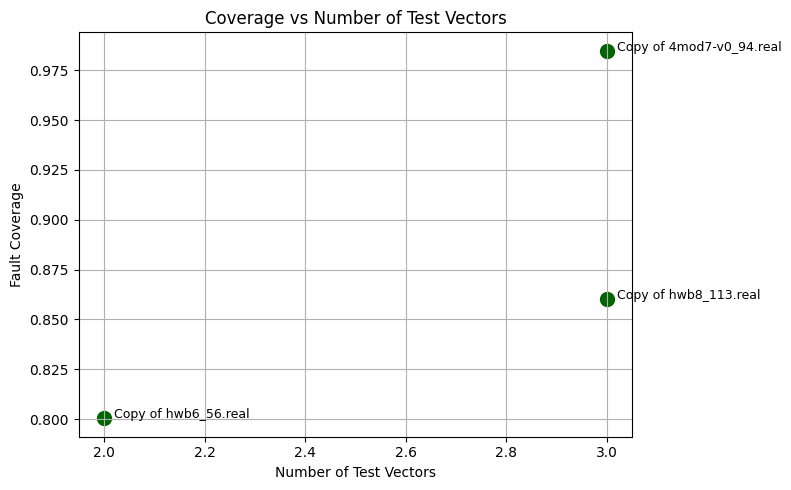

In [13]:
plot_coverage_vs_vectors(results)

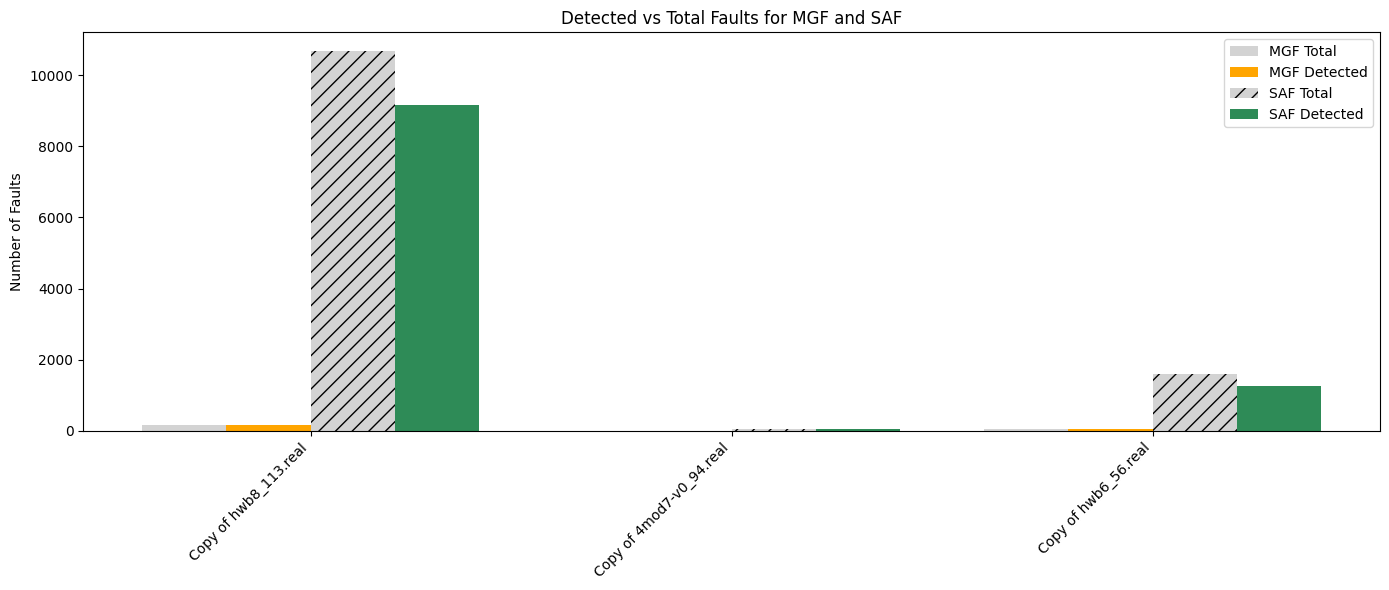

In [14]:
plot_detected_vs_total_faults(results)


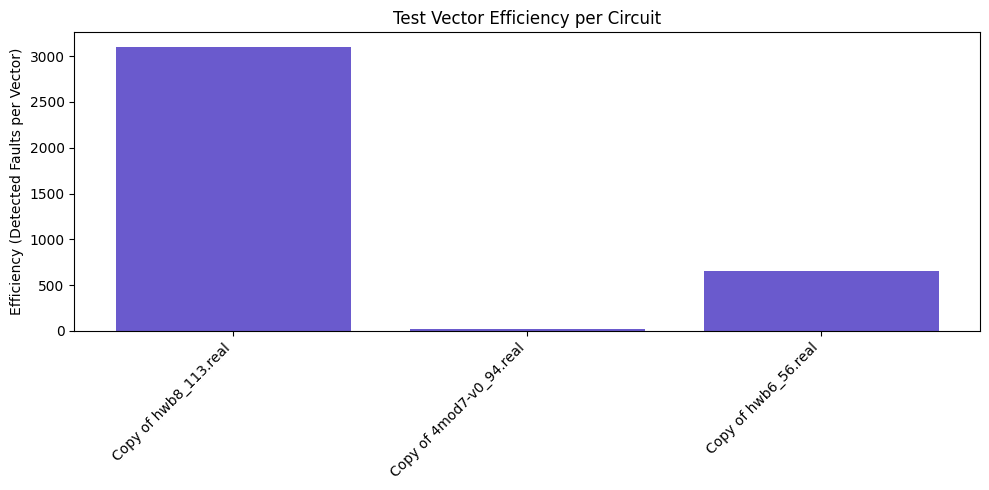

In [15]:
plot_efficiency(results)


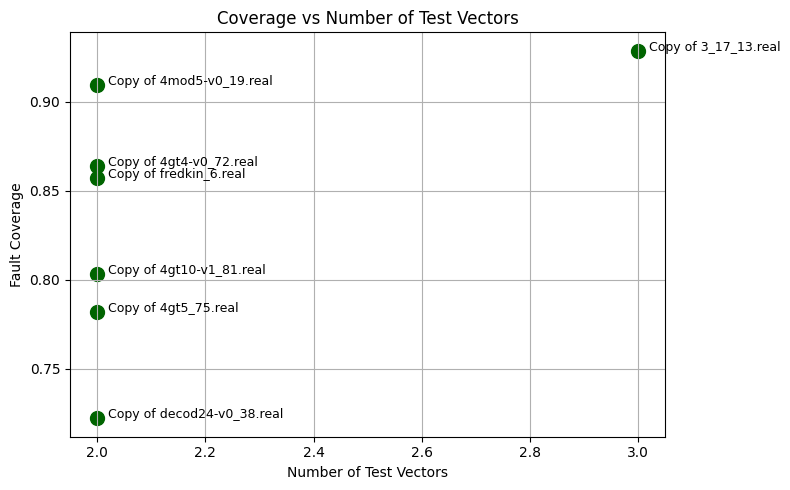

In [ ]:
# ---------- Extra Analysis Charts ---------- #
def plot_coverage_vs_vectors(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]
    x = [r["num_test_vectors"] for r in filtered]
    y = [r["coverage"] for r in filtered]
    labels = [r["file"] for r in filtered]

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, c='darkgreen', s=100)
    for i, label in enumerate(labels):
        plt.text(x[i]+0.02, y[i], label, fontsize=9)
    plt.xlabel("Number of Test Vectors")
    plt.ylabel("Fault Coverage")
    plt.title("Coverage vs Number of Test Vectors")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_detected_vs_total_faults(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]
    x = [r["file"] for r in filtered]
    total = [r["total_faults"] for r in filtered]
    detected = [r["detected_faults"] for r in filtered]

    x_pos = np.arange(len(x))
    width = 0.35
    plt.figure(figsize=(12, 6))
    plt.bar(x_pos - width/2, total, width, label='Total Faults', color='lightgray')
    plt.bar(x_pos + width/2, detected, width, label='Detected Faults', color='seagreen')

    plt.xticks(x_pos, x, rotation=45, ha='right')
    plt.ylabel("Number of Faults")
    plt.title("Detected vs Total Faults")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_efficiency(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]
    x = [r["file"] for r in filtered]
    efficiency = [r["detected_faults"] / r["num_test_vectors"] for r in filtered]

    plt.figure(figsize=(10, 5))
    plt.bar(x, efficiency, color='slateblue')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Efficiency (Detected Faults per Vector)")
    plt.title("Test Vector Efficiency per Circuit")
    plt.tight_layout()
    plt.show()

# ---------- Example Execution ---------- #
plot_coverage_vs_vectors(results)


In [ ]:
print(results)

[{'file': 'hwb6_56.real', 'fitness': 0.6187, 'coverage': 0.8187, 'total_faults': 1638, 'detected_faults': 1341, 'detected_ids': ['MGF_0', 'MGF_1', 'MGF_10', 'MGF_101', 'MGF_106', 'MGF_108', 'MGF_109', 'MGF_11', 'MGF_111', 'MGF_112', 'MGF_113', 'MGF_116', 'MGF_120', 'MGF_121', 'MGF_122', 'MGF_124', 'MGF_125', 'MGF_14', 'MGF_17', 'MGF_19', 'MGF_20', 'MGF_21', 'MGF_22', 'MGF_3', 'MGF_36', 'MGF_4', 'MGF_40', 'MGF_5', 'MGF_6', 'MGF_68', 'MGF_69', 'MGF_7', 'MGF_71', 'MGF_72', 'MGF_73', 'MGF_74', 'MGF_75', 'MGF_77', 'MGF_78', 'MGF_79', 'MGF_80', 'MGF_81', 'MGF_82', 'MGF_83', 'MGF_85', 'MGF_86', 'MGF_87', 'MGF_88', 'MGF_92', 'MGF_96', 'SAF_0_0_0', 'SAF_0_1_0', 'SAF_0_1_1', 'SAF_0_2_0', 'SAF_0_3_0', 'SAF_0_3_1', 'SAF_0_4_1', 'SAF_0_5_0', 'SAF_100_0_0', 'SAF_100_0_1', 'SAF_100_1_0', 'SAF_100_1_1', 'SAF_100_2_0', 'SAF_100_2_1', 'SAF_100_3_1', 'SAF_100_4_0', 'SAF_100_4_1', 'SAF_100_5_0', 'SAF_100_5_1', 'SAF_101_0_0', 'SAF_101_0_1', 'SAF_101_1_0', 'SAF_101_1_1', 'SAF_101_2_0', 'SAF_101_2_1', 'SAF_1